In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

In [ ]:
pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [ ]:
!pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 19.7 MB/s eta 0:00:00


## Leitura pelo terminal


In [ ]:

# --- CONFIGURAÇÃO ---
nome_arquivo = '/content/drive/MyDrive/Faculdade/IC/Códigos/resultados_df4.csv'  # Mude para o nome do seu arquivo atual

# --- LEITURA E LIMPEZA DOS DADOS ---
raw_data = []
kalman_data = []

# Regex: Procura padrões como "ax:0.123" e "R_K:10.5" dentro do texto
raw_pattern = re.compile(r"ax:([-\d.]+), ay:([-\d.]+), az:([-\d.]+), gx:([-\d.]+), gy:([-\d.]+), gz:([-\d.]+)")
kalman_pattern = re.compile(r"R_K:([-\d.eE]+), P_K:([-\d.eE]+)")

print("Lendo arquivo...")
with open(nome_arquivo, 'r') as f:
    conteudo = f.read()

    # Extrai cada bloco de números encontrado
    for match in raw_pattern.findall(conteudo):
        raw_data.append([float(x) for x in match])

    for match in kalman_pattern.findall(conteudo):
        kalman_data.append([float(x) for x in match])

# Cria tabelas de dados
df_raw = pd.DataFrame(raw_data, columns=['ax', 'ay', 'az', 'gx', 'gy', 'gz'])
df_kalman = pd.DataFrame(kalman_data, columns=['roll_k', 'pitch_k'])

# Sincroniza o tamanho das tabelas (corta excessos)
min_len = min(len(df_raw), len(df_kalman))
df_raw = df_raw.iloc[:min_len]
df_kalman = df_kalman.iloc[:min_len]

# Calcula o ângulo bruto (só acelerômetro) para comparar visualmente
# Fórmulas de trigonometria básica
df_raw['roll_acc'] = np.arctan2(df_raw['ay'], df_raw['az']) * 180 / np.pi
df_raw['pitch_acc'] = np.arctan2(-df_raw['ax'], np.sqrt(df_raw['ay']**2 + df_raw['az']**2)) * 180 / np.pi

print(f"Dados processados: {min_len} linhas.")

# --- DESENHAR OS GRÁFICOS ---
plt.figure(figsize=(12, 8))

# Gráfico 1: ROLL
plt.subplot(2, 1, 1)
plt.plot(df_raw['roll_acc'], label='Bruto (Acelerômetro)', color='lightgray', alpha=0.7)
plt.plot(df_kalman['roll_k'], label='Filtrado (Kalman)', color='blue', linewidth=2)
plt.title('Estabilidade do ROLL')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: PITCH
plt.subplot(2, 1, 2)
plt.plot(df_raw['pitch_acc'], label='Bruto (Acelerômetro)', color='lightgray', alpha=0.7)
plt.plot(df_kalman['pitch_k'], label='Filtrado (Kalman)', color='red', linewidth=2)
plt.title('Estabilidade do PITCH')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show() # Abre a janela com o gráfico

Lendo arquivo...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Faculdade/IC/Códigos/resultados_df4.csv'

## Tentando comparar os sinais

In [ ]:
path = '/content/drive/MyDrive/Faculdade/IC/Códigos/IMUSerial/IMU-Serial---IC/all_Leo_n_Gait_n_Read_ALL_Concatenated_NaN_filled.csv'

df = pd.read_csv(path)

#print(df["source"].value_counts())
# Cria um novo DataFrame contendo apenas as linhas onde 'source' é 'T7'
df_t6 = df[df['source'] == 'T6'].copy()
print(df_t6)

In [ ]:

# --- DESENHAR OS GRÁFICOS ---
# sharex=True faz com que ao dar zoom em um gráfico, os outros acompanhem o tempo
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Gráfico 1: Scatter Plot de Classes vs Tempo
ax1.plot(df_t6['t'], df_t6['S_leo'],linestyle='--', label='Classes', color='blue', alpha=0.6)
ax1.set_title('Distribuição de Classes')
ax1.set_ylabel('Classe')
#ax1.set_xlim(15 , 40)
ax1.grid(True, linestyle='--', alpha=0.6)
# Define os ticks do eixo Y para mostrar apenas inteiros (classes)
ax1.set_yticks(sorted(df_t6['S_leo'].unique()))

# Gráfico 2: Acelerômetro
ax2.plot(df_t6['t'], df_t6['A_x_4'], label='ax', color='blue', alpha=0.8)
ax2.plot(df_t6['t'], df_t6['A_y_4'], label='ay', color='magenta', alpha=0.8)
ax2.plot(df_t6['t'], df_t6['A_z_4'], label='az', color='gray', alpha=0.9)
ax2.set_title('Acelerômetro')
ax2.set_ylabel('Aceleração')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Giroscópio
ax3.plot(df_t6['t'], df_t6['G_x_4'], label='gx', color='blue', alpha=0.8)
ax3.plot(df_t6['t'], df_t6['G_y_4'], label='gy', color='magenta', alpha=0.8)
ax3.plot(df_t6['t'], df_t6['G_z_4'], label='gz', color='gray', alpha=0.9)
ax3.set_title('Giroscópio')
ax3.set_ylabel('Giro')
ax3.set_xlabel('Tempo (segundos)')
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Cria um dicionário onde a chave é o nome (ex: 'T1') e o valor é o DataFrame correspondente
dados_por_teste = {fonte: df[df['source'] == fonte].copy() for fonte in df['source'].unique()}


In [ ]:
from tslearn.metrics import soft_dtw
# Cria um dicionário onde a chave é o nome (ex: 'T1') e o valor é o DataFrame correspondente
dados_por_teste = {fonte: df[df['source'] == fonte].copy() for fonte in df['source'].unique()}

# Para acessar e usar um teste específico depois, basta chamar pela chave:
# df_t1 = dados_por_teste['T1']
# df_t5_1 = dados_por_teste['T5_1']

# Extraindo os valores em formato de array (numpy)
sinal_teste_A = dados_por_teste['T6']['G_x_4'].values
sinal_teste_B = dfk['gx'].values

# Calculando a distância
# O parâmetro gamma controla a suavidade (smoothing).
# gamma=0 equivale ao DTW tradicional (rígido). Valores como 0.1 a 1.0 são comuns para Soft-DTW.
distancia = soft_dtw(sinal_teste_A, sinal_teste_B, gamma=0)

print(f"Distância Soft-DTW: {distancia:.4f}")

In [ ]:
import matplotlib.pyplot as plt
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
import numpy as np

# Definindo um intervalo menor para visualização (ex: do ponto 1000 ao 1500)
inicio1 = 1000
fim1 = 1500

inicio2 = 2000
fim2 = 2500

trecho_A = sinal_teste_A[inicio2:fim2]
trecho_B = sinal_teste_B[inicio1:fim1]

# Calcula o caminho apenas para o trecho recortado
caminho_zoom = dtw.warping_path(trecho_A, trecho_B)

# Cria a visualização do trecho
fig, ax = dtwvis.plot_warping(trecho_A, trecho_B, caminho_zoom)

# Aumenta o tamanho da figura (Largura x Altura) para espalhar os pontos
fig.set_size_inches(15, 8)

plt.title("Zoom no Alinhamento Temporal (Amostras 1000 a 1500)")
plt.show()

### Dados sem o filtro captados pela rasp

In [ ]:
"""
# --- CONFIGURAÇÃO ---
nome_arquivo = '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/dados_coletados2.csv'  # Mude para o nome do seu arquivo atual

# --- LEITURA E LIMPEZA DOS DADOS ---
raw_data = []
kalman_data = []
class_data = []
time_data = []

# Regex: Procura padrões como "ax:0.123" e "R_K:10.5" dentro do texto
raw_pattern = re.compile(r"ax:([-\d.]+) ay:([-\d.]+) az:([-\d.]+) gx:([-\d.]+) gy:([-\d.]+) gz:([-\d.]+)")
# O \s* permite ler com ou sem espaço após os dois pontos
class_pattern = re.compile(r"Class:\s*([-\d.]+)")
kalman_pattern = re.compile(r"R_K:([-\d.eE]+) P_K:([-\d.eE]+)")
time_pattern = re.compile(r"Delay:\s*([-\d.]+)")

print("Lendo arquivo...")
with open(nome_arquivo, 'r') as f:
    conteudo = f.read()

    # Extrai cada bloco de números encontrado
    for match in raw_pattern.findall(conteudo):
        raw_data.append([float(x) for x in match])

    for match in kalman_pattern.findall(conteudo):
        kalman_data.append([float(x) for x in match])

    # CORREÇÃO AQUI:
    for match in class_pattern.findall(conteudo):
        # Colocamos entre [] para manter o formato de lista de listas para o DataFrame
        class_data.append([float(match)])

        # --- 2. LEITURA DO TEMPO ---
    for match in time_pattern.findall(conteudo):
        time_data.append(float(match))

# Cria tabelas de dados
df_raw = pd.DataFrame(raw_data, columns=['ax', 'ay', 'az', 'gx', 'gy', 'gz'])
df_class = pd.DataFrame(class_data, columns=['Class'])
df_kalman = pd.DataFrame(kalman_data, columns=['roll_k', 'pitch_k'])
# Tratamento do Tempo
# O 'Delay' costuma ser o tempo entre leituras. Usamos cumsum() para ter o tempo total corrido.
df_time = pd.DataFrame(time_data, columns=['Delay'])
df_time['Tempo_Total'] = df_time['Delay'].cumsum() / 1000 # Convertendo ms para segundos (opcional)

# --- DESENHAR OS GRÁFICOS ---
plt.figure(figsize=(12, 12))
ax = plt.gca()

# Gráfico 1: Scatter Plot de Classes vs Tempo
plt.subplot(3, 1, 1)
# s=10 define o tamanho da bolinha, alpha ajuda a ver sobreposição
plt.scatter(df_time['Tempo_Total'], df_class['Class'], label='Classes', color='blue', alpha=0.6, s=15)
plt.title('Distribuição de Classes no Tempo')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Classe')
plt.xlim(0, 5)
plt.yticks(range(-1, 7)) # Força mostrar números inteiros no eixo Y
plt.grid(True, linestyle='--', alpha=0.6)


# Gráfico 2: acelerometro
plt.subplot(3, 1, 2)
plt.plot(df_raw['ax'], label='ax', color='blue', alpha=0.8)
plt.plot(df_raw['ay'], label='ay', color='m', alpha=0.8)
plt.plot(df_raw['az'], label='az', color='gray', alpha=0.9)
plt.title('Acelerometro')
plt.xlim(1000, 2000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


# Gráfico 3: giroscopio
plt.subplot(3, 1, 3)
plt.plot(df_raw['gx'], label='gx', color='blue', alpha=0.8)
plt.plot(df_raw['gy'], label='gy', color='m', alpha=0.8)
plt.plot(df_raw['gz'], label='gz', color='gray', alpha=0.9)
plt.title('Giroscopio')
plt.xlim(1000, 2000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show() # Abre a janela com o gráfico
"""

## Dados com o filtro ou bom ou muito forte

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Lendo arquivo...


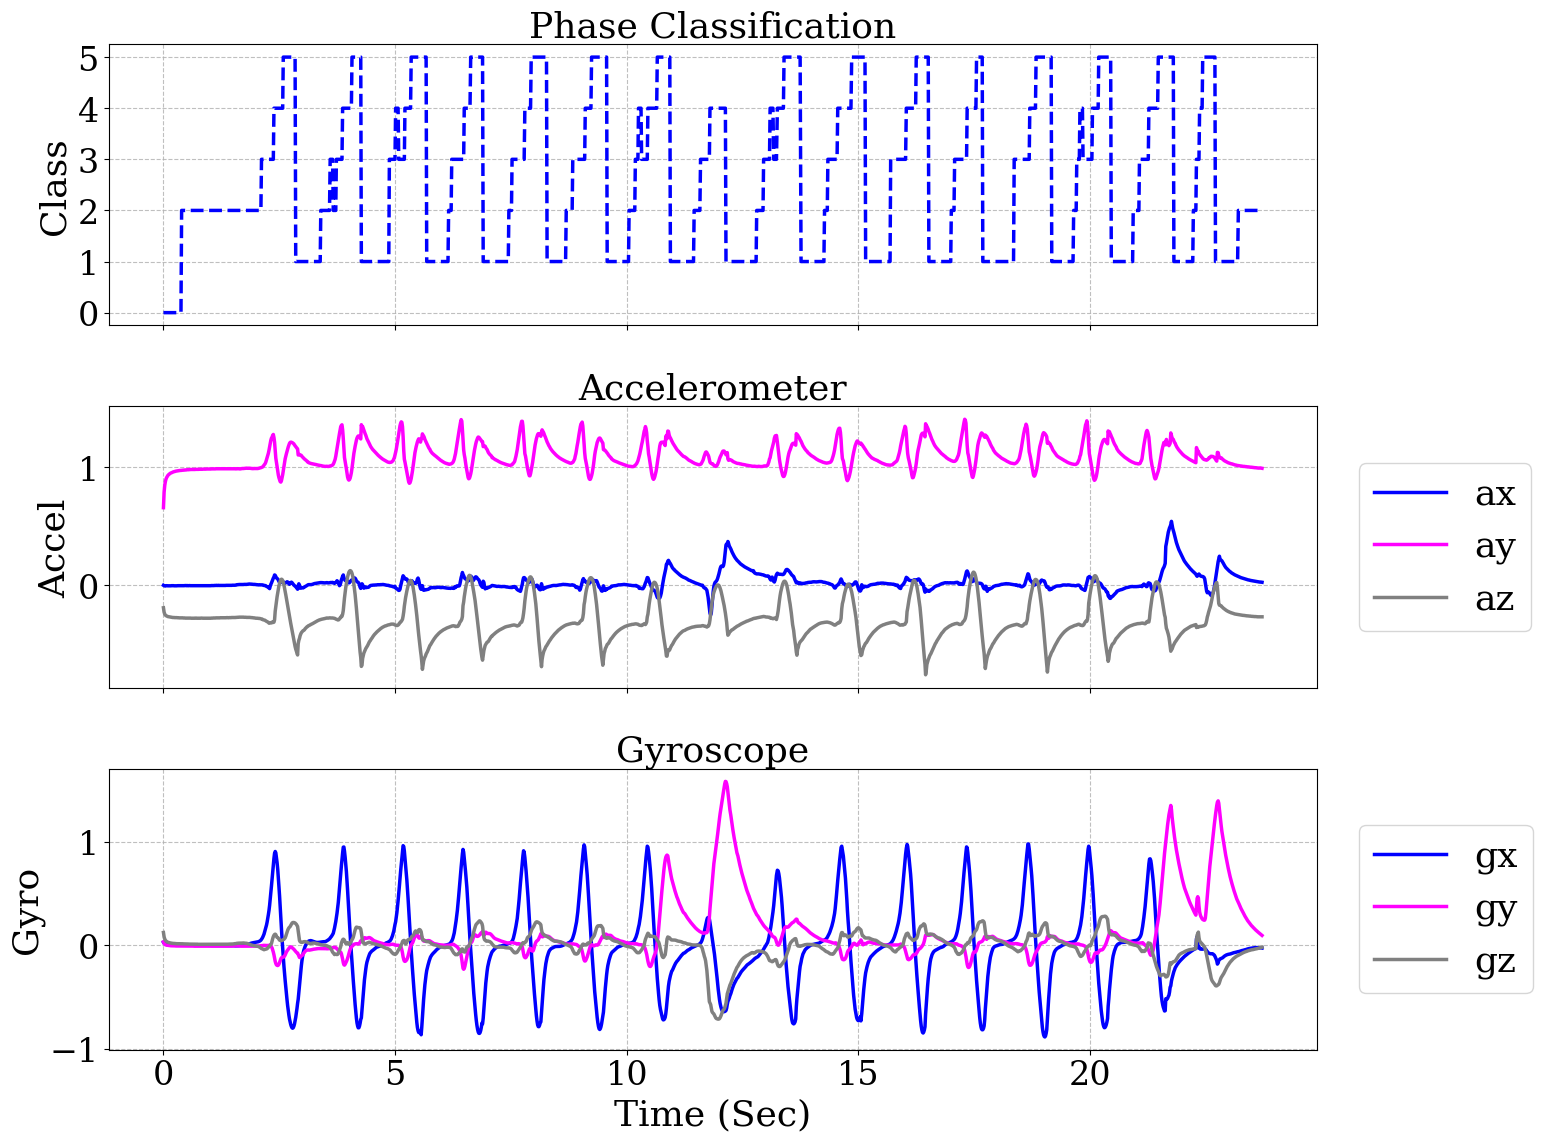

In [ ]:
from matplotlib.lines import lineStyles
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO ---
nome_arquivo = '/content/drive/MyDrive/Faculdade/IC/Resultados Pi/logs/new logs/log_runtime11_0.csv'

# --- LEITURA E TRATAMENTO DOS DADOS ---
print("Lendo arquivo...")
try:
    # Lê o CSV diretamente para um DataFrame
    dfk = pd.read_csv(nome_arquivo)

    # Ajuste de Tempo:
    # Subtrai o tempo inicial para que o gráfico comece em 0 segundos
    # Divide por 1000 assumindo que o timestamp original está em milissegundos
    tempo_inicial = dfk['timestamp'].iloc[0]
    dfk['tempo_s'] = (dfk['timestamp'] - tempo_inicial) / 1000

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado em {nome_arquivo}")
    # Cria dados fictícios apenas para testar o código se não tiver o arquivo
    dfk = pd.DataFrame(dfk)


plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman'],

    'font.size': 26,          # tamanho geral da fonte
    'axes.titlesize': 26,     # título de cada gráfico
    'axes.labelsize': 26,     # nomes dos eixos
    'xtick.labelsize': 24,    # números do eixo x
    'ytick.labelsize': 24,    # números do eixo y
    'legend.fontsize':  26  # legenda
})
# --- DESENHAR OS GRÁFICOS ---

LW = 2.5  # espessura das linhas

# sharex=True faz com que ao dar zoom em um gráfico, os outros acompanhem o tempo
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True, linewidth = 20)
#dfk['gx']=(dfk['gx'].values)
#
#dfk['gy']=(dfk['gy'].values)
#
#dfk['gz']=(dfk['gz'].values)
#
#
#dfk['ax']=(dfk['ax'].values)
#dfk['ay']=(dfk['ay'].values)
##dfk['az']=(dfk['az'].values) * (-1)

# Gráfico 1: Scatter Plot de Classes vs Tempo
ax1.plot(dfk['tempo_s'], dfk['classe_prevista'],linestyle='--', label='Classes', color='blue', alpha=1, linewidth = LW)
ax1.set_title('Phase Classification')
ax1.set_ylabel('Class')
#ax1.set_xlim(3 , 10)
ax1.grid(True, linestyle='--', alpha=0.8,  which = "major")
# Define os ticks do eixo Y para mostrar apenas inteiros (classes)
ax1.set_yticks(sorted(dfk['classe_prevista'].unique()))
# Gráfico 2: Acelerômetro
ax2.plot(dfk['tempo_s'], dfk['ax'], label='ax', color='blue', linewidth=LW)
ax2.plot(dfk['tempo_s'], dfk['ay'], label='ay', color='magenta', linewidth=LW)
ax2.plot(dfk['tempo_s'], dfk['az'], label='az', color='gray', linewidth=LW)
ax2.set_title('Accelerometer')
ax2.set_ylabel('Accel')
ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
ax2.grid(True, linestyle='--', alpha=0.8, which="major")

# Gráfico 3: Giroscópio
ax3.plot(dfk['tempo_s'], dfk['gx'], label='gx', color='blue', linewidth=LW)
ax3.plot(dfk['tempo_s'], dfk['gy'], label='gy', color='magenta', linewidth=LW)
ax3.plot(dfk['tempo_s'], dfk['gz'], label='gz', color='gray', linewidth=LW)
ax3.set_title('Gyroscope')
ax3.set_ylabel('Gyro')
ax3.set_xlabel('Time (Sec)')
ax3.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
ax3.grid(True, linestyle='--', alpha=0.8, which="major")

plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.tight_layout()
plt.show()


In [ ]:
print(dfk.columns)


Index(['timestamp', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'roll', 'pitch_k',
       'acc_norm', 'gyro_norm', 'classe_prevista_raw', 'classe_prevista',
       'delay_ms', 'tempo_s'],
      dtype='object')


## Criando Dataset

In [ ]:

# Cria a coluna vazia
dfk['Fase'] = 'Desconhecida'

In [ ]:
dfk

,timestamp,ax,ay,az,gx,gy,gz,roll,pitch_k,acc_norm,gyro_norm,classe_prevista_raw,classe_prevista,delay_ms,tempo_s,Fase
0,1780148176404,0.020352,0.669005,-0.140997,-0.013027,-0.003504,0.005795,92.646,-1.55016,1.02567,0.02495,0,0,3.354,0.000,Desconhecida
1,1780148176418,0.025000,0.800000,-0.171000,-0.015000,-0.005000,0.005000,97.216,-1.69600,1.01800,0.02000,0,0,3.322,0.014,Desconhecida
2,1780148176433,0.029000,0.858000,-0.177000,-0.018000,-0.008000,0.003000,98.393,-1.84400,1.02300,0.03000,0,0,5.159,0.029,Desconhecida
3,1780148176447,0.030000,0.890000,-0.182000,-0.019000,-0.010000,-0.001000,99.140,-1.85300,1.02000,0.03100,0,0,3.528,0.043,Desconhecida
4,1780148176461,0.028000,0.910000,-0.188000,-0.017000,-0.011000,-0.002000,99.735,-1.68600,1.02200,0.02000,0,0,3.340,0.057,Desconhecida
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,1780148202505,0.084000,1.071000,-0.496000,-0.315000,0.279000,0.025000,93.549,-2.14100,1.09200,0.22900,1,1,4.751,26.101,Desconhecida
1900,1780148202520,0.082000,1.066000,-0.486000,-0.301000,0.263000,0.027000,94.671,-2.15200,0.99600,0.18100,1,1,3.815,26.116,Desconhecida
1901,1780148202533,0.078000,1.063000,-0.475000,-0.288000,0.248000,0.029000,95.491,-1.97600,1.01900,0.16200,1,1,3.243,26.129,Desconhecida
1902,1780148202547,0.078000,1.061000,-0.464000,-0.276000,0.235000,0.031000,96.168,-2.19300,1.04300,0.13600,1,1,3.251,26.143,Desconhecida


In [ ]:
!pip install ipympl

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

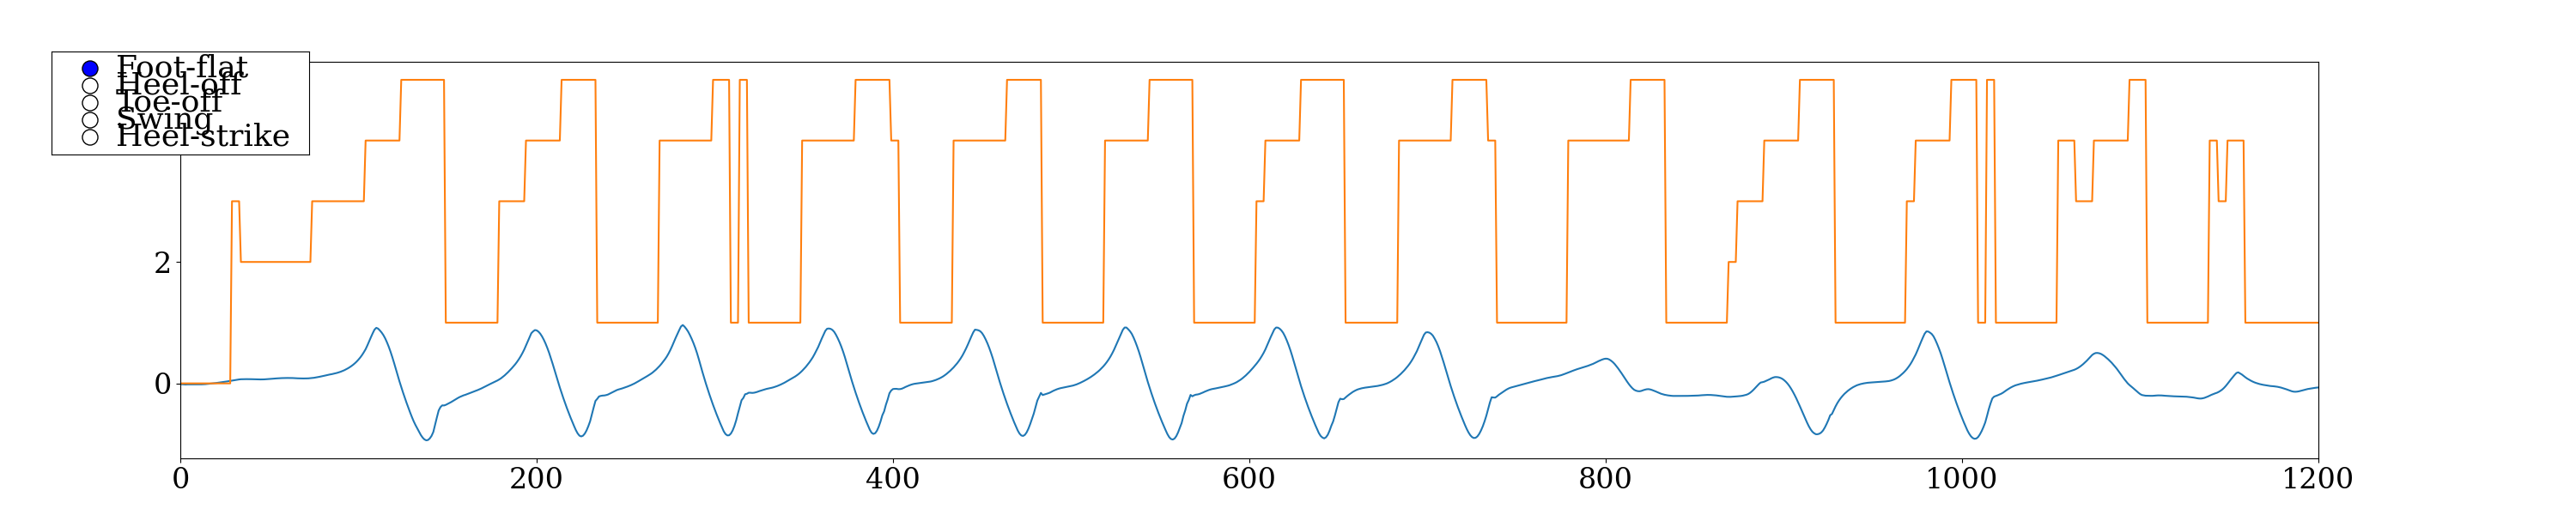

In [ ]:
# Habilita gráficos interativos no Jupyter/Colab
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector, RadioButtons

# Lista que vai guardar todas as suas seleções
selecoes_salvas = []

fig, ax = plt.subplots(figsize=(30, 6))
plt.subplots_adjust(left=0.07) # Abre espaço para o menu lateral
ax.plot(dfk.index, dfk['gx'])
ax.plot(dfk.index, dfk['classe_prevista'])  # Usando o index (Número da Amostra) no eixo X
ax.set_xlim(0, 1200)
# Cria o menu de Radio Buttons na esquerda
ax_radio = plt.axes([0.02, 0.7, 0.1, 0.2])
opcoes_fases = ('Foot-flat', 'Heel-off', 'Toe-off', 'Swing', 'Heel-strike')
radio = RadioButtons(ax_radio, opcoes_fases)

# Cores para feedback visual
cores = {'Foot-flat':'yellow', 'Heel-off':'red', 'Toe-off':'purple', 'Swing':'green', 'Heel-strike':'blue'}

def ao_selecionar(xmin, xmax):
    fase_atual = radio.value_selected
    selecoes_salvas.append((xmin, xmax, fase_atual))

    # Pinta o fundo do gráfico para você saber o que já foi selecionado
    ax.axvspan(xmin, xmax, facecolor=cores[fase_atual], alpha=0.3)
    fig.canvas.draw_idle()
    print(f", ( {xmin:.0f}, {xmax:.0f}, '{fase_atual}')")

# Ativa a ferramenta de clicar e arrastar
span = SpanSelector(ax, ao_selecionar, 'horizontal', useblit=True, props=dict( facecolor='gray'))

plt.show()
#'Foot-flat':'yellow', 'Heel-off':'red', 'Toe-off':'purple', 'Swing':'green', 'Heel-strike':'blue'

In [ ]:
"""dfk['gx'] = dfk['gx']*(-1)"""


"dfk['gx'] = dfk['gx']*(-1)"

In [ ]:
import numpy as np
import pandas as pd

# Cria a coluna com um valor padrão caso não exista
if 'Fase' not in dfk.columns:
    dfk['Fase'] = 'Desconhecida'

# Lista completa extraída da sua seleção interativa
selecoes_salvas = [
]

# Varre a lista e preenche o DataFrame
for inicio, fim, fase in selecoes_salvas:
    # Seleciona as amostras pelo índice e atualiza a coluna
    dfk.loc[inicio:fim, 'Fase'] = fase

# Converte as strings para os números que a sua Random Forest espera
mapeamento_classes = {
    'Heel-strike': 1,
    'Foot-flat': 2,
    'Heel-off': 3,
    'Toe-off': 4,
    'Swing': 5,
    'Desconhecida': 0 # Para os gaps que ficaram sem seleção
}

print(f"Sucesso! Valores preenchidos.")
print(dfk['Fase'].value_counts())

Sucesso! Valores preenchidos.
Fase
Swing           283
Desconhecida    236
Foot-flat       236
Heel-strike     166
Toe-off         118
Heel-off        113
Name: count, dtype: int64


In [ ]:
dfk['Fase'] = dfk['Fase'].replace({
    'Heel-strike': 1,
    'Foot-flat': 2,
    'Heel-off': 3,
    'Toe-off': 4,
    'Swing': 5,
    'Desconhecida': 0
})

/tmp/ipykernel_5401/1056577635.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfk['Fase'] = dfk['Fase'].replace({


In [ ]:
dfk

,timestamp,ax,ay,az,gx,gy,gz,roll,pitch_k,acc_norm,gyro_norm,classe_prevista_raw,classe_prevista,delay_ms,tempo_s,Fase
0,1778532773107,0.022143,0.670145,-0.130252,0.000539,-0.005346,0.00292,91.8257,-1.689,1.02423,0.010391,0,0,3.315,0.000,0
1,1778532773120,0.025000,0.804000,-0.156000,0.001000,-0.007000,0.00500,96.1750,-1.660,1.02200,0.013000,0,0,3.286,0.013,0
2,1778532773134,0.028000,0.860000,-0.167000,0.001000,-0.007000,0.00500,97.7610,-1.760,1.01900,0.010000,0,0,3.286,0.027,0
3,1778532773149,0.030000,0.892000,-0.173000,0.001000,-0.008000,0.00500,98.6090,-1.831,1.02100,0.010000,0,0,5.237,0.042,0
4,1778532773163,0.032000,0.911000,-0.175000,0.001000,-0.007000,0.00500,99.0000,-1.926,1.01500,0.007000,0,0,3.306,0.056,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,1778532788816,-0.012000,1.006000,-0.300000,-0.010000,0.003000,-0.00400,106.0370,1.355,0.97800,0.065000,2,2,3.257,15.709,0
1148,1778532788829,-0.012000,1.004000,-0.299000,-0.011000,0.003000,-0.00100,106.0240,1.249,0.99700,0.080000,2,2,3.226,15.722,0
1149,1778532788842,-0.012000,1.003000,-0.298000,-0.013000,0.003000,0.00100,105.9860,1.283,1.02400,0.085000,2,2,3.791,15.735,0
1150,1778532788856,-0.011000,1.003000,-0.297000,-0.014000,0.003000,0.00300,105.8970,1.001,1.04600,0.059000,2,2,3.238,15.749,0


##Final Fase

In [ ]:
dfk

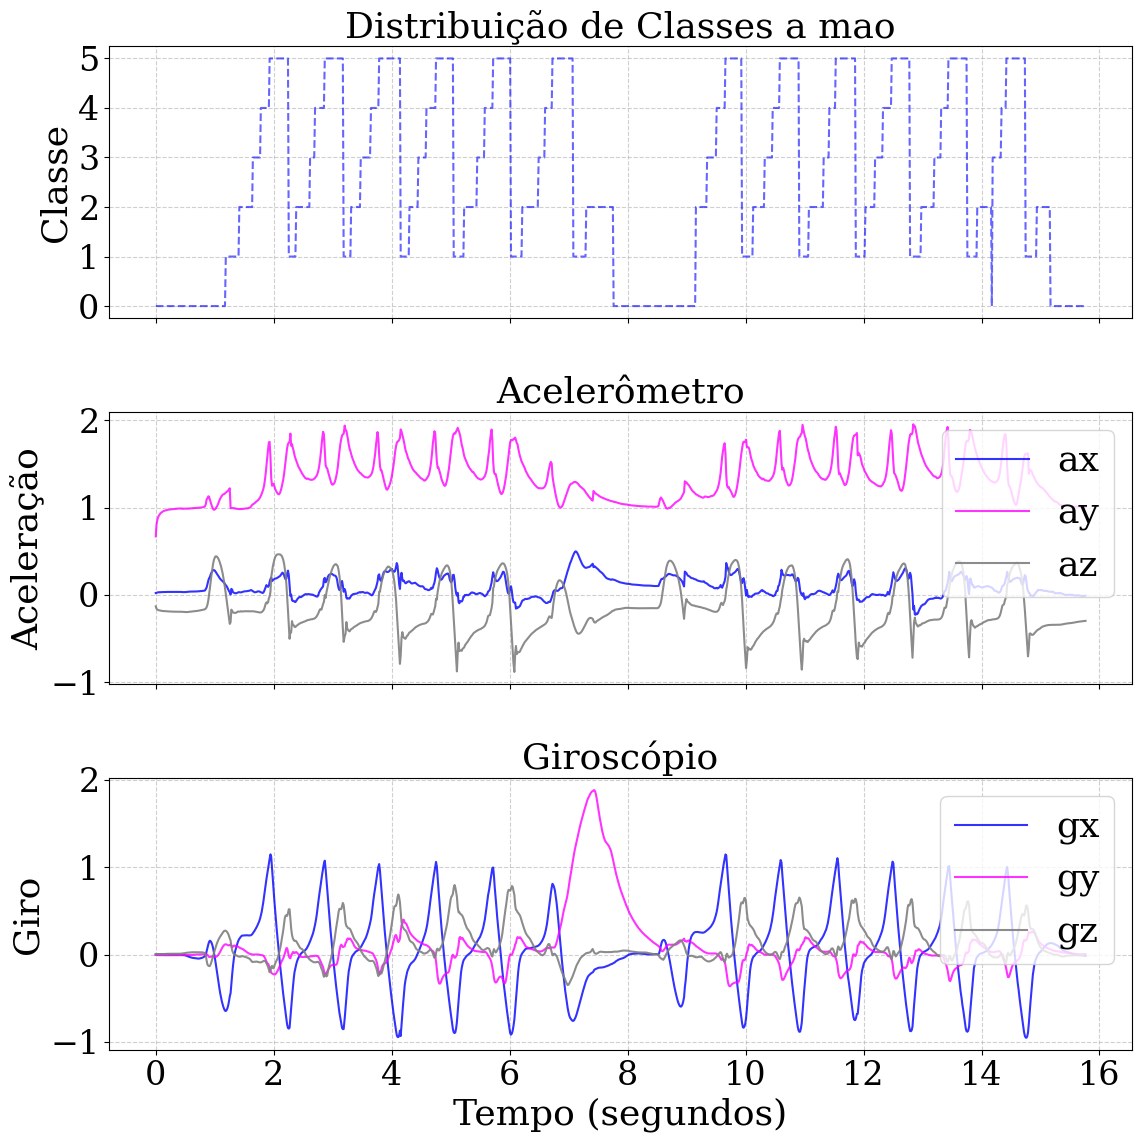

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
# sharex=True faz com que ao dar zoom em um gráfico, os outros acompanhem o tempo
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
# Gráfico 1: Scatter Plot de Classes vs Tempo
ax1.plot(dfk['tempo_s'], dfk['Fase'],linestyle='--', label='Classes', color='blue', alpha=0.6)
ax1.set_title('Distribuição de Classes a mao')
ax1.set_ylabel('Classe')
#ax1.set_xlim(15 , 30)
ax1.grid(True, linestyle='--', alpha=0.6)
# Define os ticks do eixo Y para mostrar apenas inteiros (classes)
ax1.set_yticks(sorted(dfk['Fase'].unique()))

# Gráfico 2: Acelerômetro
ax2.plot(dfk['tempo_s'], dfk['ax'], label='ax', color='blue', alpha=0.8)
ax2.plot(dfk['tempo_s'], dfk['ay'], label='ay', color='magenta', alpha=0.8)
ax2.plot(dfk['tempo_s'], dfk['az'], label='az', color='gray', alpha=0.9)
ax2.set_title('Acelerômetro')
ax2.set_ylabel('Aceleração')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Giroscópio
ax3.plot(dfk['tempo_s'], dfk['gx'], label='gx', color='blue', alpha=0.8)
ax3.plot(dfk['tempo_s'], dfk['gy'], label='gy', color='magenta', alpha=0.8)
ax3.plot(dfk['tempo_s'], dfk['gz'], label='gz', color='gray', alpha=0.9)
ax3.set_title('Giroscópio')
ax3.set_ylabel('Giro')
ax3.set_xlabel('Tempo (segundos)')
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
# 1. Salva o DataFrame como um arquivo CSV
nome_do_arquivo = 'log_rot7_3.csv'

# O index=False evita que o pandas crie uma coluna extra inútil com o número da linha
dfk.to_csv(nome_do_arquivo, index=False)

print(f"Arquivo '{nome_do_arquivo}' criado no ambiente!")

# 2. Faz o download automático para o seu computador (específico para Google Colab)
try:
    from google.colab import files
    files.download(nome_do_arquivo)
    print("Download iniciado...")
except ImportError:
    print("Você não está no Colab. O arquivo foi salvo na pasta atual do seu projeto.")

Arquivo 'log_rot7_3.csv' criado no ambiente!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado...
